In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


2025-11-19 18:59:53.073979: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-19 18:59:53.074046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-19 18:59:53.077782: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
subj1 = np.load('../Data/subj1.npz')
subj2 = np.load('../Data/subj2.npz')

volumes = np.stack([subj1['vol'], subj2['vol']]).astype('float32')
vol_shape = volumes.shape[1:]
print('Loaded volumes:', volumes.shape, 'vol_shape:', vol_shape)

x_train_tensor = torch.from_numpy(volumes).unsqueeze(1)
x_val_tensor = torch.from_numpy(volumes.copy()).unsqueeze(1)

pair_indices = torch.tensor(
    [(i, j) for i in range(len(volumes)) for j in range(len(volumes)) if i != j],
    dtype=torch.long
)
print('Total ordered training pairs:', pair_indices.shape[0])


Loaded volumes: (2, 160, 192, 224) vol_shape: (160, 192, 224)
Total ordered training pairs: 2


In [3]:
def sample_batch(x_data, batch_size=1, device=device, pairs=pair_indices):
    idx = torch.randint(0, pairs.shape[0], (batch_size,))
    combo = pairs[idx]
    moving = x_data[combo[:, 0]].to(device)
    fixed = x_data[combo[:, 1]].to(device)
    return moving, fixed


In [4]:
class SpatialTransformer3D(nn.Module):
    def forward(self, src, flow):
        b, _, d, h, w = src.shape
        device = src.device

        zz, yy, xx = torch.meshgrid(
            torch.arange(d, device=device),
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        base_grid = torch.stack((xx, yy, zz), dim=0).float()
        base_grid = base_grid.unsqueeze(0).repeat(b, 1, 1, 1, 1)
        base_grid = base_grid.to(flow)

        pts = base_grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0
        z = 2.0 * (pts[:, 2] / (d - 1.0)) - 1.0

        grid = torch.stack((x, y, z), dim=-1)

        warped = F.grid_sample(
            src,
            grid,
            mode='bilinear',
            padding_mode='border',
            align_corners=True
        )
        return warped


In [5]:
def flow_grad_l2(flow):
    dx = flow[:, :, :, :, 1:] - flow[:, :, :, :, :-1]
    dy = flow[:, :, :, 1:, :] - flow[:, :, :, :-1, :]
    dz = flow[:, :, 1:, :, :] - flow[:, :, :-1, :, :]
    dx = F.pad(dx, (0, 1, 0, 0, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1, 0, 0))
    dz = F.pad(dz, (0, 0, 0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean() + dz.pow(2).mean()


In [6]:
class ConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense3D(nn.Module):
    def __init__(self, vol_shape, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)):
        super().__init__()
        self.vol_shape = vol_shape
        self.encoders = nn.ModuleList()
        in_channels = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock3D(in_channels, nf))
            in_channels = nf
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3D(enc_feats[-1], enc_feats[-1])

        self.decoders = nn.ModuleList()
        decoder_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock3D(decoder_in + skip_ch, skip_ch))
            decoder_in = skip_ch

        self.final_conv0 = ConvBlock3D(decoder_in, final_feats[0])
        self.final_conv1 = ConvBlock3D(final_feats[0], final_feats[1])
        self.flow = nn.Conv3d(final_feats[1], 3, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer3D()

        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv3d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='leaky_relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, src, tgt):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='trilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        moved = self.transformer(src, flow)
        return moved, flow


In [7]:
model = VxmDense3D(vol_shape=vol_shape, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [8]:
model.eval()
with torch.no_grad():
    moving, fixed = sample_batch(x_train_tensor, batch_size=1, device=device)
    moved, flow = model(moving, fixed)
print('moved:', tuple(moved.shape), 'flow:', tuple(flow.shape))


moved: (1, 1, 160, 192, 224) flow: (1, 3, 160, 192, 224)


In [9]:
torch.cuda.empty_cache()

batch_size = 1
steps_per_epoch = max(16, pair_indices.shape[0])
epochs = 400
patience = 10
smooth_weight = 0.01

history = []
best_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for _ in range(steps_per_epoch):
        moving, fixed = sample_batch(x_train_tensor, batch_size=batch_size, device=device)
        moved, flow = model(moving, fixed)
        recon_loss = F.mse_loss(moved, fixed)
        smooth_loss = flow_grad_l2(flow)
        loss = recon_loss + smooth_weight * smooth_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / steps_per_epoch
    history.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{epochs} -- loss: {epoch_loss:.6f} (recon {recon_loss.item():.6f}, smooth {smooth_loss.item():.6f})")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

history = np.array(history, dtype=np.float32)


Epoch 1/400 -- loss: 0.002644 (recon 0.002652, smooth 0.000073)
Epoch 2/400 -- loss: 0.002630 (recon 0.002643, smooth 0.000069)
Epoch 3/400 -- loss: 0.002617 (recon 0.002642, smooth 0.000092)
Epoch 4/400 -- loss: 0.002588 (recon 0.002628, smooth 0.000125)
Epoch 5/400 -- loss: 0.002571 (recon 0.002527, smooth 0.000490)
Epoch 6/400 -- loss: 0.002353 (recon 0.002203, smooth 0.006791)
Epoch 7/400 -- loss: 0.002204 (recon 0.002073, smooth 0.007209)
Epoch 8/400 -- loss: 0.002106 (recon 0.001982, smooth 0.010865)
Epoch 9/400 -- loss: 0.002003 (recon 0.001847, smooth 0.012827)
Epoch 10/400 -- loss: 0.001918 (recon 0.001736, smooth 0.014960)
Epoch 11/400 -- loss: 0.001846 (recon 0.001642, smooth 0.016555)
Epoch 12/400 -- loss: 0.001780 (recon 0.001548, smooth 0.018941)
Epoch 13/400 -- loss: 0.001718 (recon 0.001511, smooth 0.020026)
Epoch 14/400 -- loss: 0.001660 (recon 0.001403, smooth 0.021850)
Epoch 15/400 -- loss: 0.001607 (recon 0.001343, smooth 0.023143)
Epoch 16/400 -- loss: 0.001573 (re

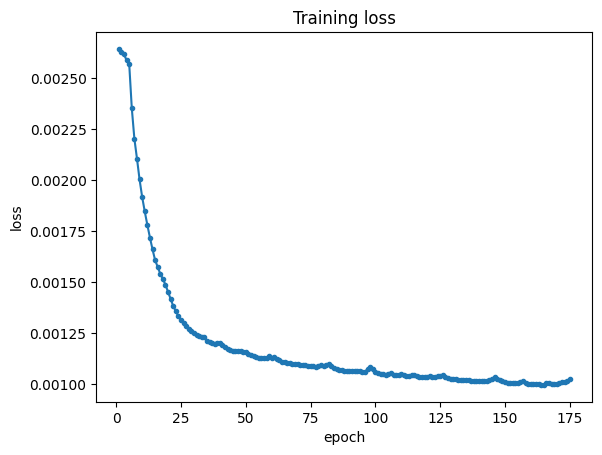

In [10]:
plt.figure()
plt.plot(np.arange(1, len(history) + 1), history, '.-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss')
plt.show()


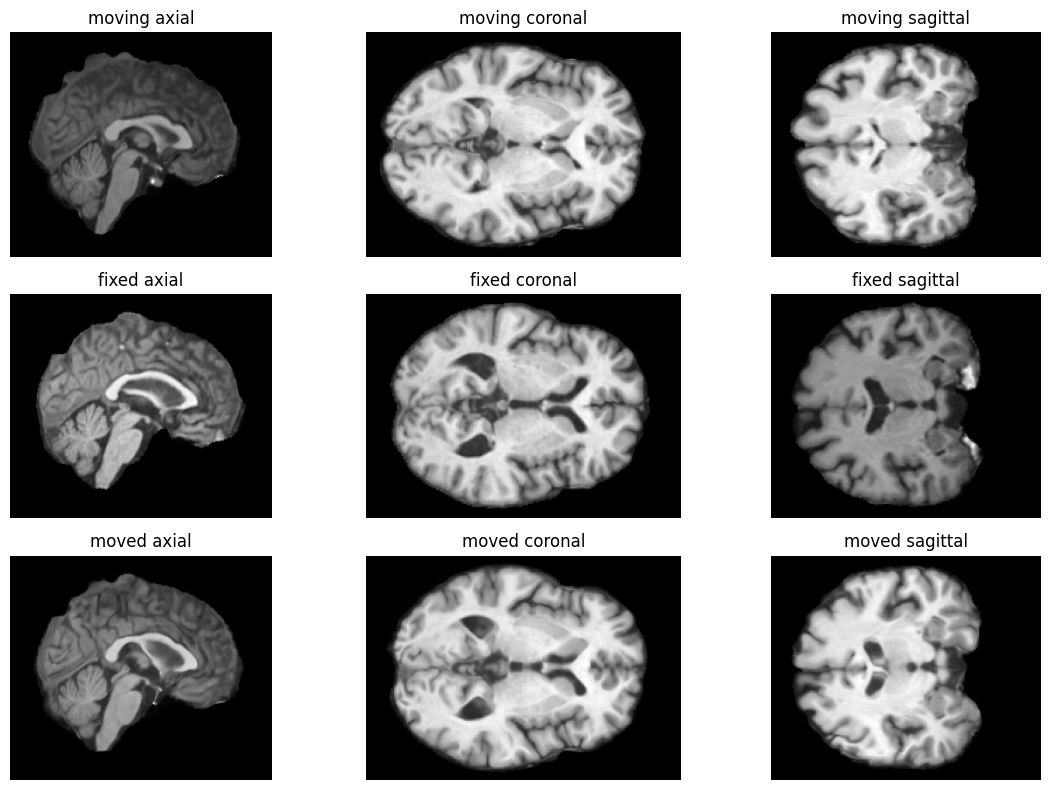

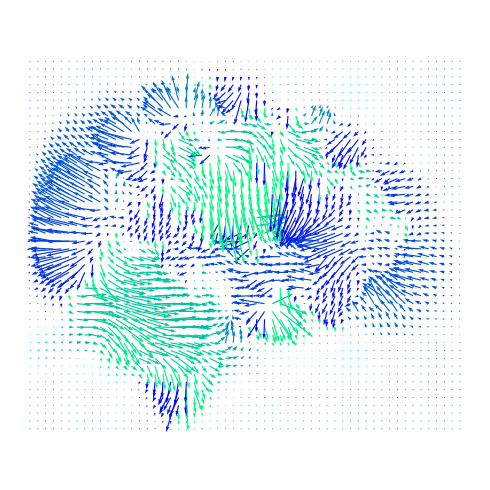

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [11]:
model.eval()
with torch.no_grad():
    moving, fixed = sample_batch(x_val_tensor, batch_size=1, device=device)
    moved, flow = model(moving, fixed)

# visualize orthogonal slices for qualitative check

def mid_slices(volume):
    axial = volume[volume.shape[0] // 2]
    coronal = volume[:, volume.shape[1] // 2, :]
    sagittal = volume[:, :, volume.shape[2] // 2]
    return [axial, coronal, sagittal]

trio = [('moving', moving[0, 0].cpu().numpy()),
        ('fixed', fixed[0, 0].cpu().numpy()),
        ('moved', moved[0, 0].cpu().numpy())]

plt.figure(figsize=(12, 8))
views = ['axial', 'coronal', 'sagittal']
for row, (title, vol) in enumerate(trio):
    for col, (view, slc) in enumerate(zip(views, mid_slices(vol))):
        idx = row * 3 + col + 1
        plt.subplot(len(trio), 3, idx)
        plt.imshow(slc, cmap='gray')
        plt.title(f'{title} {view}')
        plt.axis('off')
plt.tight_layout()
plt.show()

flow_np = flow[0].permute(1, 2, 3, 0).cpu().numpy()
mid_z = flow_np.shape[0] // 2
flow_axial = flow_np[mid_z, :, :, :2]
step = 4
flow_axial_ds = flow_axial[::step, ::step, :]
ne.plot.flow([flow_axial_ds], width=5)


In [12]:
import os
save_dir = '../trained_weights'
os.makedirs(save_dir, exist_ok=True)
dense3d_path = os.path.join(save_dir, '3d_dense.pth')
torch.save(model.state_dict(), dense3d_path)
print('Saved 3D model to', dense3d_path)


Saved 3D model to ../trained_weights/3d_dense.pth
